**Machine learning Python**

In [2]:
import sklearn

In [4]:
import pandas as pd
import numpy as np
# Lecture des données
## Charger les données ou les lire directement en précisant le chemin
path="../divers/"
data=pd.read_csv(path+"healthcare_synthetic_data.csv",sep=",",header=0)
# Vérification du contenu
data.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [5]:
data=data.drop('Patient_ID',axis=1)

In [6]:
data["Gender"]=pd.Categorical(data["Gender"],ordered=False)
data["Smoking_Status"]=pd.Categorical(data["Smoking_Status"],ordered=False)
data["Alcohol_Consumption"]=pd.Categorical(data["Alcohol_Consumption"],ordered=False)
data["Physical_Activity_Level"]=pd.Categorical(data["Physical_Activity_Level"],ordered=True)
data["Family_History"]=pd.Categorical(data["Family_History"],ordered=False)
data["Heart_Disease_Risk"]=pd.Categorical(data["Heart_Disease_Risk"],ordered=False)


In [ ]:
data.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


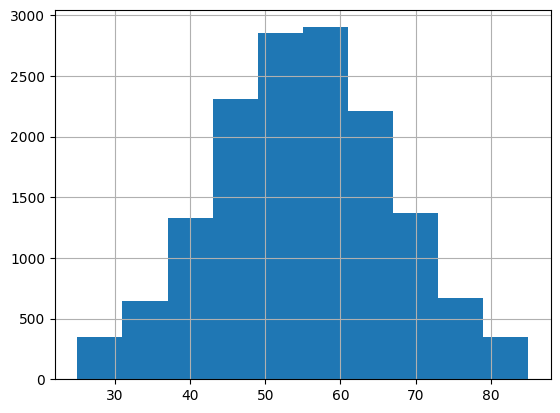

In [7]:
import matplotlib.pyplot as plt
data["Age"].hist()
plt.show()

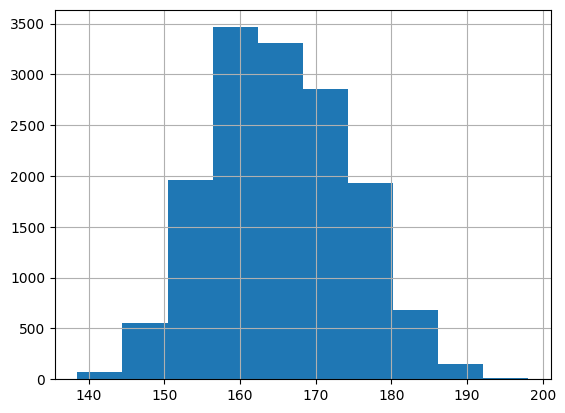

In [8]:
data["Height_cm"].hist()
plt.show()

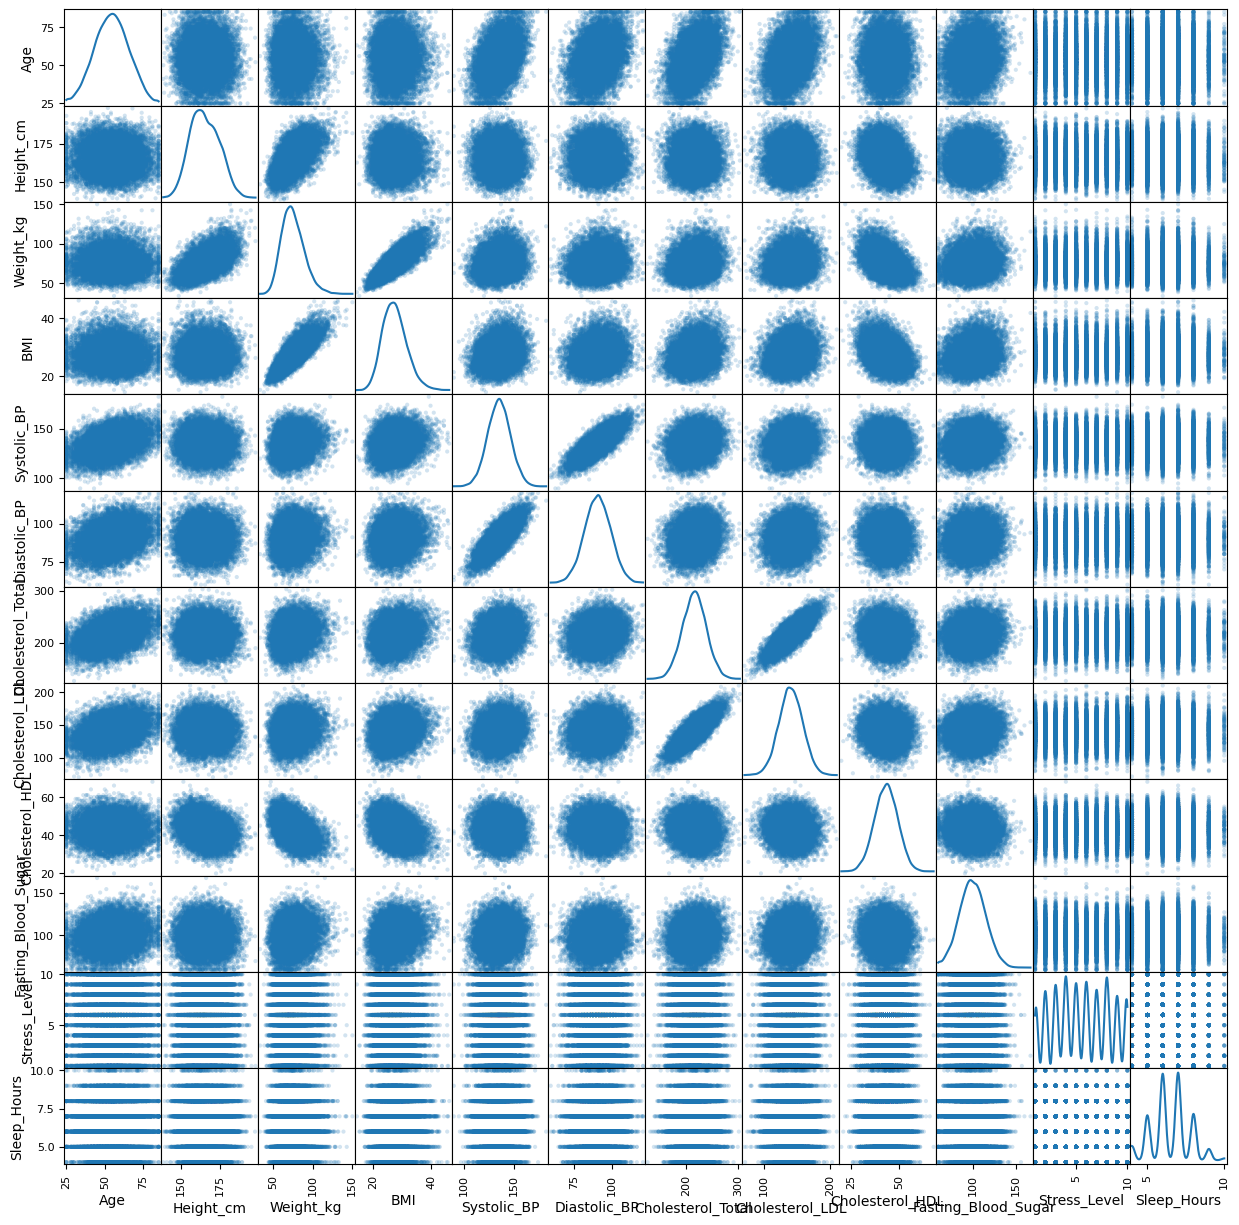

In [9]:
from pandas.plotting import scatter_matrix
scatter_matrix(data[["Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP","Cholesterol_Total","Cholesterol_LDL","Cholesterol_HDL","Fasting_Blood_Sugar","Stress_Level","Sleep_Hours"]], alpha=0.2, 
               figsize=(15, 15), diagonal='kde')
plt.show()

In [10]:
# Variables explicatives
dataDum=pd.get_dummies(data[["Gender","Smoking_Status","Alcohol_Consumption","Physical_Activity_Level","Family_History"]])
dataDum.head()

,Gender_0,Gender_1,Smoking_Status_0,Smoking_Status_1,Alcohol_Consumption_0,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_0,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_0,Family_History_1
0,True,False,True,False,False,True,False,False,False,False,True,True,False
1,True,False,True,False,True,False,False,False,True,False,False,True,False
2,False,True,True,False,True,False,False,True,False,False,False,True,False
3,False,True,True,False,True,False,False,False,True,False,False,True,False
4,False,True,True,False,False,True,False,False,False,True,False,True,False


In [11]:
del dataDum["Gender_0"]
del dataDum["Smoking_Status_0"]
del dataDum["Family_History_0"]

In [12]:
dataQuant=data[["Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP","Cholesterol_Total","Cholesterol_LDL","Cholesterol_HDL","Fasting_Blood_Sugar","Stress_Level","Sleep_Hours"]]
dataC=pd.concat([dataDum,dataQuant],axis=1)
dataC.head()

,Gender_1,Smoking_Status_1,Alcohol_Consumption_0,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_0,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1,...,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
0,False,False,False,True,False,False,False,False,True,False,...,51.3,23.8,140,89,217,151,52,83,1,8
1,False,False,True,False,False,False,True,False,False,False,...,76.6,29.3,128,81,203,119,38,116,7,9
2,True,False,True,False,False,True,False,False,False,False,...,92.4,30.3,141,100,173,124,45,90,1,7
3,True,False,True,False,False,False,True,False,False,False,...,68.9,22.9,136,96,193,117,45,81,2,7
4,True,False,False,True,False,False,False,True,False,False,...,79.8,25.0,122,80,236,153,41,79,2,6


In [13]:
# variable à expliquer binaire (risque d'AVC)
Yb=data["Heart_Disease_Risk"]
# variable à expliquer quantitative (cholestérol)
Yr=data["Cholesterol_LDL"]

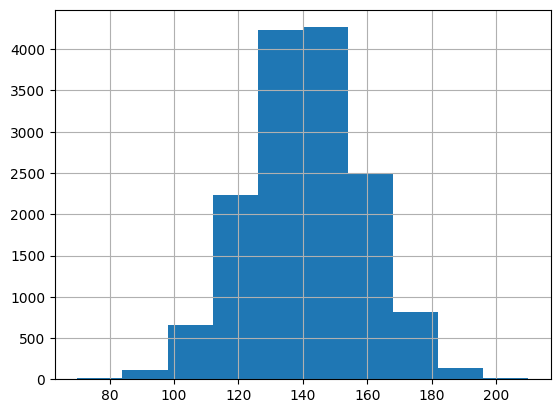

In [14]:
Yr.hist()
plt.show()

Séparation des deux échantillons (train et test)

In [15]:
from sklearn.model_selection import train_test_split  
X_train,X_test,Y_train_AVC,Y_test_AVC=train_test_split(dataC,Yb,test_size=3000,random_state=11)
X_train,X_test,Y_train_cholest,Y_test_cholest=train_test_split(dataC,Yr,test_size=3000,random_state=11)

In [16]:
from sklearn.preprocessing import StandardScaler  
# L'algorithme des réseaux de neurones nécessite éventuellement une normalisation 
# des variables explicatives avec les commandes ci-dessous
scaler = StandardScaler()  
scaler.fit(X_train)
Xr_train = scaler.transform(X_train)  
# Meme transformation sur le test
Xr_test = scaler.transform(X_test)

PArtie knn et SVM 

PArtie AVC

PArtie kNN : 

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [22]:
from sklearn.neighbors import KNeighborsClassifier
# Optimisation de k
# grille de valeurs
param_grid=[{"n_neighbors":list(range(1,15))}]
knn=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,n_jobs=-1)
knnOpt=knn.fit(Xr_train,Y_train_AVC)  # GridSearchCV est lui même un estimateur
# paramètre optimal
knnOpt.best_params_["n_neighbors"]
print("Meilleur score = %f, Meilleur paramètre = %s" % (1.-knnOpt.best_score_,knnOpt.best_params_))

Meilleur score = 0.289250, Meilleur paramètre = {'n_neighbors': 13}


In [25]:
# Estimation de l'erreur de prévision sur l'échantillon test
1-knnOpt.score(X_train,Y_train_AVC)

/home/gugubre/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


0.5658333333333334

In [26]:
# Prévision de l'échantillon test
y_chap = knnOpt.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_AVC)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1330  583
1                    340  747


Passons mainteant à la SVM

In [31]:
from sklearn.svm import SVC
param=[{"C":[0.4,0.5,0.6,0.8,1,1.4]}]
svm= GridSearchCV(SVC(),param,cv=10,n_jobs=-1)
svmOpt=svm.fit(Xr_train, Y_train_AVC)
# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt.best_score_,svmOpt.best_params_))

Meilleur score = 0.269083, Meilleur paramètre = {'C': 1}


In [32]:
# erreur de prévision sur le test
1-svmOpt.score(Xr_test,Y_test_AVC)

0.2746666666666666

In [34]:
# prévision de l'échantillon test
y_chap = svmOpt.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_AVC)
print(table)

Heart_Disease_Risk     0    1
row_0                        
0                   1376  530
1                    294  800


PArtie Cholesterol

In [35]:
from sklearn.neighbors import KNeighborsClassifier
# Optimisation de k
# grille de valeurs
param_grid=[{"n_neighbors":list(range(1,15))}]
knn=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,n_jobs=-1)
knnOpt=knn.fit(Xr_train,Y_train_cholest)  # GridSearchCV est lui même un estimateur
# paramètre optimal
knnOpt.best_params_["n_neighbors"]
print("Meilleur score = %f, Meilleur paramètre = %s" % (1.-knnOpt.best_score_,knnOpt.best_params_))

/home/gugubre/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Meilleur score = 0.966750, Meilleur paramètre = {'n_neighbors': 1}


In [43]:
# Estimation de l'erreur de prévision sur l'échantillon test
1-knnOpt.score(X_test,Y_test_cholest)

/home/gugubre/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


1.0

In [40]:
# Prévision de l'échantillon test
y_chap = knnOpt.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_cholest)
print(table)

Cholesterol_LDL  76   83   85   86   88   90   91   92   93   94   ...  186  \
row_0                                                              ...        
90                 0    0    0    0    0    0    0    0    0    0  ...    0   
91                 0    0    0    0    0    0    0    0    0    0  ...    0   
94                 0    0    0    0    0    0    0    0    0    0  ...    0   
95                 0    1    0    0    0    0    0    0    0    0  ...    0   
96                 0    0    0    0    0    0    0    1    0    0  ...    0   
...              ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
183                0    0    0    0    0    0    0    0    0    0  ...    0   
185                0    0    0    0    0    0    0    0    0    0  ...    0   
187                0    0    0    0    0    0    0    0    0    0  ...    0   
191                0    0    0    0    0    0    0    0    0    0  ...    0   
200                0    0    0    0    0    0    0  

SVM

In [41]:
from sklearn.svm import SVC
param=[{"C":[0.4,0.5,0.6,0.8,1,1.4]}]
svm= GridSearchCV(SVC(),param,cv=10,n_jobs=-1)
svmOpt=svm.fit(Xr_train, Y_train_cholest)
# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt.best_score_,svmOpt.best_params_))

/home/gugubre/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


Meilleur score = 0.914500, Meilleur paramètre = {'C': 1.4}


In [44]:
# erreur de prévision sur le test
1-svmOpt.score(Xr_test,Y_test_cholest)

0.9136666666666666

In [45]:
# prévision de l'échantillon test
y_chap = svmOpt.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_cholest)
print(table)

Cholesterol_LDL  76   83   85   86   88   90   91   92   93   94   ...  186  \
row_0                                                              ...        
100                0    0    1    0    0    1    1    0    0    0  ...    0   
101                0    0    0    0    0    1    0    0    0    0  ...    0   
103                0    0    0    0    0    0    0    1    0    0  ...    0   
104                1    0    0    1    0    0    0    0    0    1  ...    0   
105                0    0    0    0    0    0    0    0    0    0  ...    0   
...              ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
177                0    0    0    0    0    0    0    0    0    0  ...    0   
178                0    0    0    0    0    0    0    0    0    0  ...    1   
179                0    0    0    0    0    0    0    0    0    0  ...    0   
180                0    0    0    0    0    0    0    0    0    0  ...    0   
186                0    0    0    0    0    0    0  